In [1]:
import commot as ct
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [1]:
adata=sc.read_h5ad('/home/lixinxing/IBD/data_sp/2025_05_16_code/adata_merge_3_sub_newname.h5ad')
adata=adata.raw.to_adata()

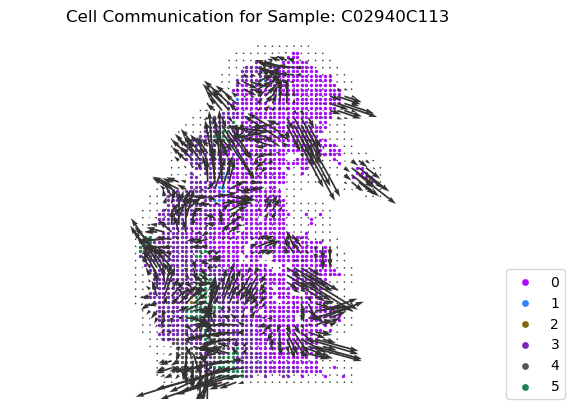

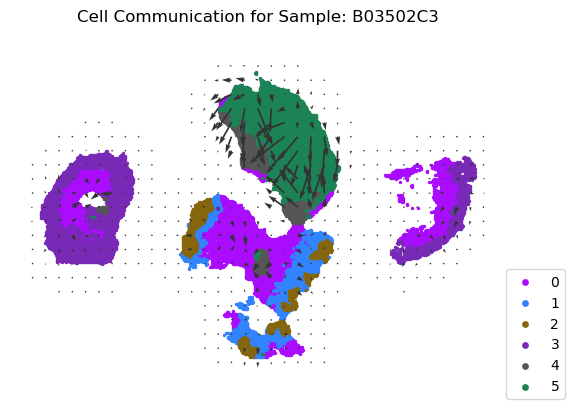

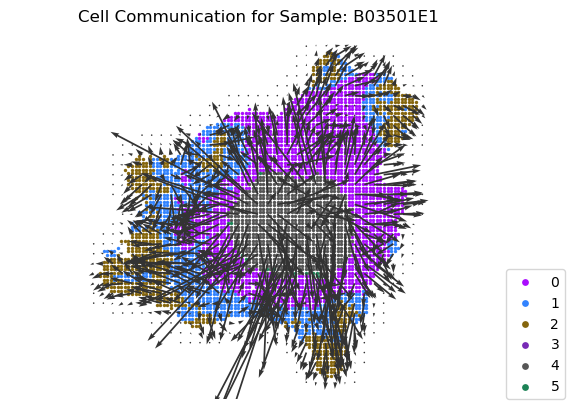

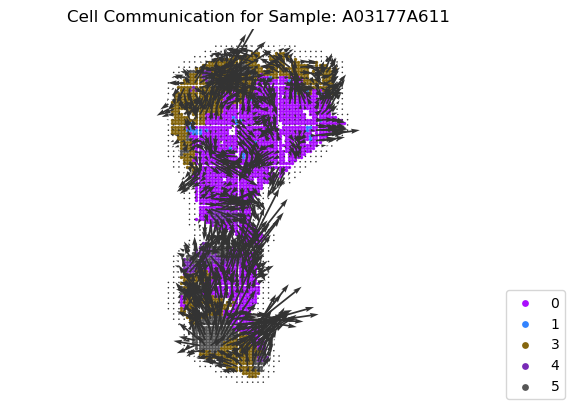

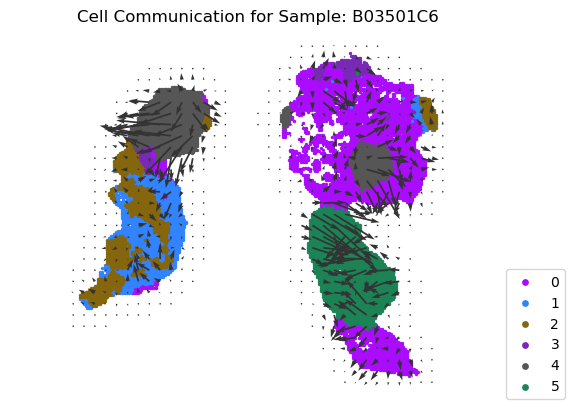

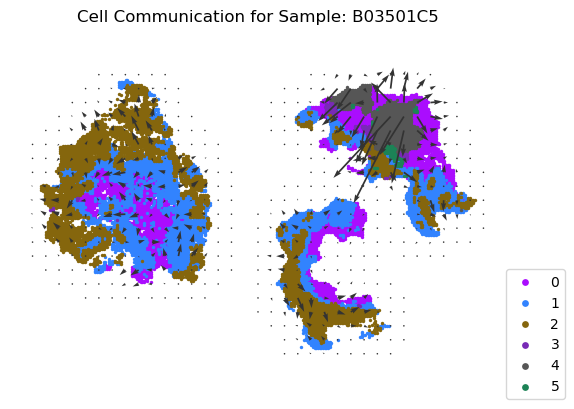

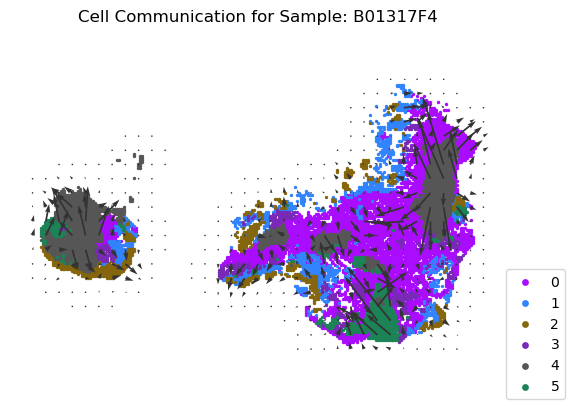

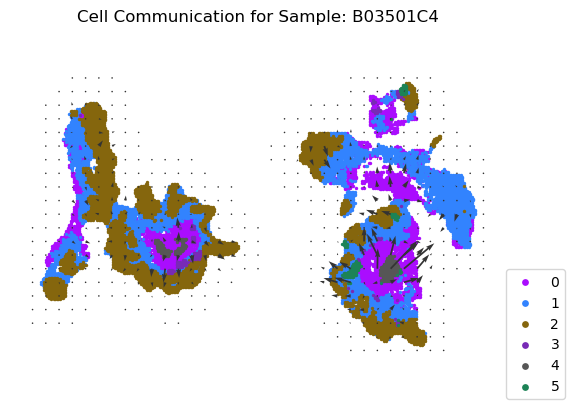

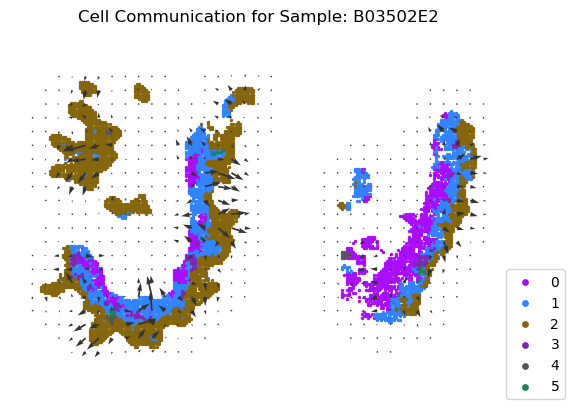

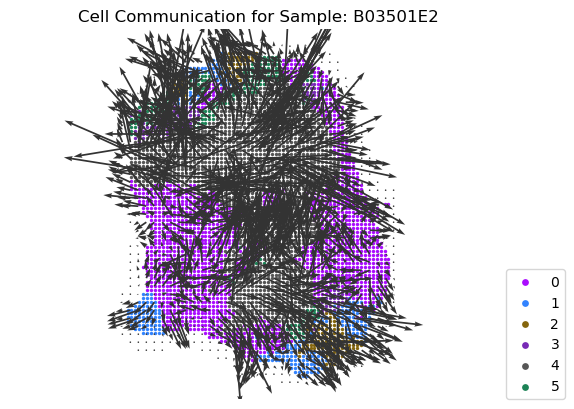

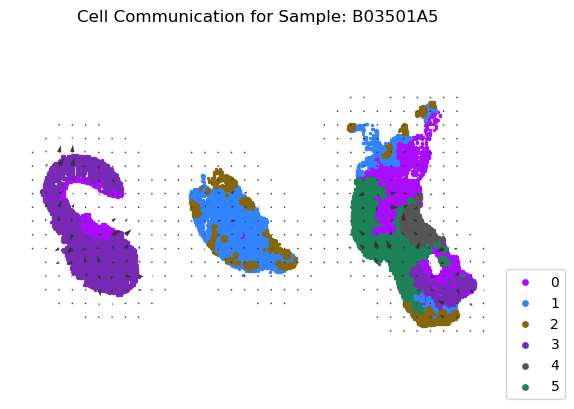

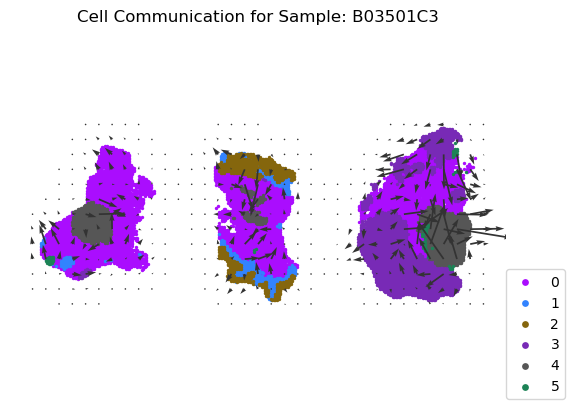

In [142]:
import matplotlib.pyplot as plt

processed_adata_list = []
samples = adata.obs['sample'].unique()

for sample in samples:

    adata_sample = adata[adata.obs['sample'] == sample]

    df_ligrec = ct.pp.ligand_receptor_database(database='CellChat', species='human')
    df_ligrec = df_ligrec[df_ligrec.iloc[:, 2].isin(['CXCL'])]
    df_cellchat = ct.pp.filter_lr_database(df_ligrec, adata_sample, min_cell_pct=0.001)  
    df_cellchat_filtered = df_cellchat

    ct.tl.spatial_communication(adata_sample, database_name='cellchat', df_ligrec=df_cellchat_filtered, dis_thr=500, 
                                heteromeric=True, pathway_sum=True)

    pathway = 'CXCL'
    ct.tl.communication_direction(adata_sample, database_name='cellchat', pathway_name=pathway, k=5)

    ct.pl.plot_cell_communication(adata_sample, database_name='cellchat', pathway_name=pathway, plot_method='grid', 
                                   background_legend=True, stream_linewidth=0.5, stream_density=0.5, 
                                   grid_width=0.0035, scale=0.00001, ndsize=6, grid_density=0.7, 
                                   summary='receiver', background='cluster', clustering='leiden_new', 
                                   normalize_v=True, normalize_v_quantile=0.995)

    plt.title(f"Cell Communication for Sample: {sample}")
    plt.show()
    processed_adata_list.append(adata_sample)

# for idx, adata_sample in enumerate(processed_adata_list):
#     adata_sample.write(f'processed_adata_sample_{samples[idx]}.h5ad')

In [2]:
test=sc.concat(processed_adata_list,join='outer')
test.write_h5ad('/home/lixinxing/IBD/Crosstalk/COMMOT/adata_cxcl12_cxcr4.h5ad')